# Assignment 4 (new data) — 4. Improved CNN models

**"New architecture = old architecture + one mechanism addressing one limitation."**

`theory_notes.md` §3 sets out the improvement techniques and then §3.3 measures four of them on CIFAR-10.
This notebook repeats that experiment on the **new** image data, so the conclusions can be checked on a
different problem rather than assumed to transfer.

Four models, each the previous one plus **exactly one** mechanism — the same ladder, the same
`variants.py` code the original `04_compare.ipynb` used:

| Model | Adds | The limitation it targets (§3.2) |
|---|---|---|
| **M1** | `Conv + ReLU + Pool` | — (baseline) |
| **M2** | `+ BatchNorm` | activations drift between layers and batches |
| **M3** | `+ Residual`, $Y = F(X) + X$ | depth stops helping; gradients need a direct path |
| **M4** | `+ SE channel attention` | channels are not equally useful |

Then a fifth experiment, **data augmentation** (§3.2a), which is the one technique on that list that adds
*no parameters at all*.

### What §3.3 found on CIFAR-10, for comparison

| Model | Params | Accuracy | vs M1 |
|---|---:|---:|---:|
| M1 | 72,730 | 69.47 % | — |
| M2 | 72,954 | **75.24 %** | **+5.77** |
| M3 | 75,786 | **76.39 %** | **+6.92** |
| M4 | 78,614 | 73.67 % | +4.20 |

BatchNorm was the big win for 224 extra parameters; the residual added a little more; **attention made
things worse**. The question here is whether any of that reproduces.

### Why a deliberately small training set

Notebook 02 showed a plain two-convolution CNN getting very close to the ceiling on the rice images — they
are pre-segmented, centred, perfectly balanced grains on a black background. An architecture comparison run
at the ceiling measures nothing: every model scores ~99 % and the differences are noise.

So this notebook trains on a **4,000-image slice**. That is not a trick to flatter the improvements — it is
the regime where regularisation and normalisation are *supposed* to matter, and it leaves enough headroom
for a real difference between M1 and M4 to show up if one exists.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))        # notebook/  -> ass4_newdata
sys.path.insert(0, os.path.abspath(".."))       # repo root  -> ass4_utils, variants

import ass4_newdata as D
import ass4_utils as U
import variants as V

import torch
import torch.nn as nn

U.set_seed(U.SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS = D.notebook_results_dir()
MODELS = D.use_notebook_model_dir()

# variants.py caches trained weights under its own CACHE_DIR, which by default
# points at results/variant_cache/ and already holds the CIFAR-10 M1..M4 run.
# Redirect it, or this notebook would silently load those CIFAR models and
# report them as rice results.
V.CACHE_DIR = os.path.join(MODELS, "variant_cache_rice")
os.makedirs(V.CACHE_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("variant cache ->", os.path.relpath(V.CACHE_DIR, D.HERE))

torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU
variant cache -> models\variant_cache_rice


---
## 1. The data

4,000 training images, 2,000 test, 32×32 — the same stratified split and the same seed as notebook 02, just
a smaller slice of it.

In [2]:
N_TRAIN, N_TEST = 4_000, 2_000

X_train, y_train, X_test, y_test, meta = D.load_rice(
    img_size=32, n_train=N_TRAIN, n_test=N_TEST)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)
DATASET = meta["name"]

print(f"\ntrain {X_train.shape}   test {X_test.shape}")
print(f"per-class train counts: {np.bincount(y_train)}")

  cache hit  data\cache\rice_32.npz


Rice (4k subset): train (4000, 3, 32, 32) / test (2000, 3, 32, 32), 5 classes

train (4000, 3, 32, 32)   test (2000, 3, 32, 32)
per-class train counts: [785 786 847 808 774]


---
## 2. The four models

`variants.py` builds all four from one `VariantCNN` class with three boolean switches, which is what
guarantees that M2 really is M1-plus-BatchNorm and nothing else. Two details of that design are worth
naming:

- **Three stages of two 3×3 convolutions**, widths 16 → 32 → 64. Deliberately narrow, so four models
  finish in reasonable time.
- **Global average pooling instead of flatten.** Notebook 02 measured its `Flatten → Dense` head holding
  **96 %** of that model's parameters. Replacing it with GAP is why these models cost ~72k parameters
  instead of ~544k while being *deeper*.

In [3]:
V.EPOCHS, V.BATCH_SIZE, V.LR = 10, 128, 1e-3

rows = []
for name in V.VARIANTS:
    m = V.build(name, in_ch=C, n_classes=N_CLASSES)
    total = sum(p.numel() for p in m.parameters())
    rows.append({"model": name, "n_params": total, **V.VARIANTS[name]})

arch = pd.DataFrame(rows)
arch["added vs previous"] = arch["n_params"].diff().fillna(0).astype(int)
display(arch)

print(f"\nwidths {V.WIDTHS}, {V.EPOCHS} epochs, batch {V.BATCH_SIZE}, Adam(lr={V.LR})")
print(f"M4 costs {arch['n_params'].iloc[-1] - arch['n_params'].iloc[0]:,} more parameters than M1 "
      f"({(arch['n_params'].iloc[-1] / arch['n_params'].iloc[0] - 1):.1%})")

,model,n_params,use_bn,use_residual,use_se,added vs previous
0,M1 Conv+ReLU+Pool,72405,False,False,False,0
1,M2 + BatchNorm,72629,True,False,False,224
2,M3 + Residual,75461,True,True,False,2832
3,M4 + Attention(SE),78289,True,True,True,2828



widths [16, 32, 64], 10 epochs, batch 128, Adam(lr=0.001)
M4 costs 5,884 more parameters than M1 (8.1%)


In [4]:
print(V.build("M4  + Attention(SE)", in_ch=C, n_classes=N_CLASSES))

VariantCNN(
  (stages): Sequential(
    (0): Stage(
      (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential(
        (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (se): SEBlock(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=16, out_features=4, bias=True)
          (1): ReLU()
          (2): Linear(in_features=4, out_features=16, bias=True)
          (3): Sigmoid()
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2,

---
## 3. Training the ladder

Each run is cached to `notebook/models/variant_cache_rice/`, so an interrupted session resumes instead of
starting over. Delete that folder to force a clean retrain.

In [5]:
ladder = []
for name in V.VARIANTS:
    rec = V.train_variant(
        name, X_train, y_train, X_test, y_test, N_CLASSES,
        device=DEVICE, epochs=V.EPOCHS, batch_size=V.BATCH_SIZE, lr=V.LR, seed=U.SEED,
    )
    # train_variant labels its record with the dataset the original experiment
    # used; this run is on different data, so correct it before it is reported.
    rec = dict(rec)
    rec["dataset"] = DATASET
    ladder.append(rec)

ladder_df = pd.DataFrame([{k: v for k, v in r.items()
                           if k not in ("history", "confusion")} for r in ladder])
display(ladder_df.round(4))


=== M1  Conv+ReLU+Pool  (72,405 parameters) ===


  epoch  1/10  loss 1.3296  test_acc 0.6370
  epoch  2/10  loss 0.7425  test_acc 0.6650


  epoch  3/10  loss 0.6296  test_acc 0.7200
  epoch  4/10  loss 0.5645  test_acc 0.7035


  epoch  5/10  loss 0.5788  test_acc 0.6970
  epoch  6/10  loss 0.5458  test_acc 0.6870


  epoch  7/10  loss 0.5669  test_acc 0.7150
  epoch  8/10  loss 0.5128  test_acc 0.6785


...

  epoch  7/10  loss 0.0139  test_acc 0.9825


  epoch  8/10  loss 0.0157  test_acc 0.9910


  epoch  9/10  loss 0.0066  test_acc 0.9930


  epoch 10/10  loss 0.0052  test_acc 0.9945
  final: accuracy 0.9945  macro-F1 0.9945  (13s)  [cached]


,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,PyTorch,Rice (4k subset),M1 Conv+ReLU+Pool,72405,10,2.46,0.4510,0.8015,0.8040,0.8054,0.8024
1,PyTorch,Rice (4k subset),M2 + BatchNorm,72629,10,6.45,0.0130,0.9895,0.9896,0.9894,0.9894
2,PyTorch,Rice (4k subset),M3 + Residual,75461,10,10.08,0.0076,0.9895,0.9896,0.9893,0.9893
3,PyTorch,Rice (4k subset),M4 + Attention(SE),78289,10,13.40,0.0052,0.9945,0.9946,0.9944,0.9945


In [6]:
base_acc = ladder[0]["test_accuracy"]
summary = pd.DataFrame([{
    "model": r["model"],
    "n_params": r["n_params"],
    "test_accuracy": r["test_accuracy"],
    "f1_macro": r["f1_macro"],
    "train_loss": r["train_loss"],
    "train_seconds": r["train_seconds"],
    "vs M1 (points)": round(100 * (r["test_accuracy"] - base_acc), 2),
} for r in ladder])
display(summary.round(4))

,model,n_params,test_accuracy,f1_macro,train_loss,train_seconds,vs M1 (points)
0,M1 Conv+ReLU+Pool,72405,0.8015,0.8024,0.4510,2.46,0.0
1,M2 + BatchNorm,72629,0.9895,0.9894,0.0130,6.45,18.8
2,M3 + Residual,75461,0.9895,0.9893,0.0076,10.08,18.8
3,M4 + Attention(SE),78289,0.9945,0.9945,0.0052,13.40,19.3


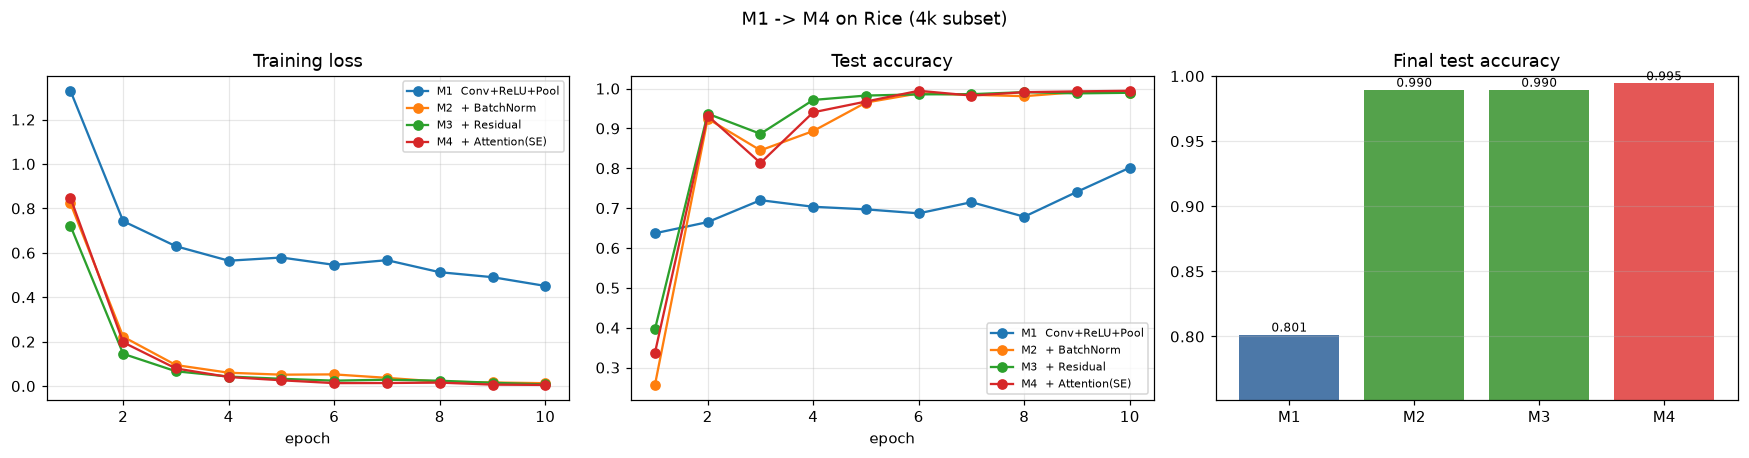

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for r in ladder:
    axes[0].plot(range(1, len(r["history"]["loss"]) + 1), r["history"]["loss"],
                 marker="o", label=r["model"])
    axes[1].plot(range(1, len(r["history"]["val_acc"]) + 1), r["history"]["val_acc"],
                 marker="o", label=r["model"])
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch")
axes[1].set_title("Test accuracy"); axes[1].set_xlabel("epoch")
for a in axes[:2]:
    a.grid(alpha=0.3); a.legend(fontsize=7)

axes[2].bar(range(len(ladder)), [r["test_accuracy"] for r in ladder],
            color=["#4C78A8", "#54A24B", "#54A24B", "#E45756"])
axes[2].set_xticks(range(len(ladder)), [r["model"].split()[0] for r in ladder])
axes[2].set_title("Final test accuracy")
axes[2].set_ylim(min(r["test_accuracy"] for r in ladder) - 0.05, 1.0)
axes[2].grid(alpha=0.3, axis="y")
for i, r in enumerate(ladder):
    axes[2].text(i, r["test_accuracy"], f"{r['test_accuracy']:.3f}",
                 ha="center", va="bottom", fontsize=8)

fig.suptitle(f"M1 -> M4 on {DATASET}")
fig.tight_layout(); plt.show()

### Is M4 overfitting, the way it did on CIFAR-10?

The tell §3.3 identified was **lowest training loss but not the best test accuracy** — fitting the training
data better while generalising worse. The cell below checks for that signature directly instead of assuming
it reappears.

In [8]:
best_acc = max(r["test_accuracy"] for r in ladder)
low_loss = min(r["train_loss"] for r in ladder)

for r in ladder:
    flags = []
    if r["train_loss"] == low_loss:
        flags.append("lowest train loss")
    if r["test_accuracy"] == best_acc:
        flags.append("best test accuracy")
    print(f"{r['model']:<22} train loss {r['train_loss']:.4f}   "
          f"test acc {r['test_accuracy']:.4f}   {', '.join(flags)}")

winner = max(ladder, key=lambda r: r["test_accuracy"])
loss_winner = min(ladder, key=lambda r: r["train_loss"])
print()
if winner["model"] != loss_winner["model"]:
    print(f"OVERFITTING SIGNATURE PRESENT: {loss_winner['model']} fits the training data best "
          f"but {winner['model']} generalises better.")
else:
    print(f"No overfitting signature: {winner['model']} wins on both training loss and test accuracy.")

M1  Conv+ReLU+Pool     train loss 0.4510   test acc 0.8015   
M2  + BatchNorm        train loss 0.0130   test acc 0.9895   
M3  + Residual         train loss 0.0076   test acc 0.9895   
M4  + Attention(SE)    train loss 0.0052   test acc 0.9945   lowest train loss, best test accuracy

No overfitting signature: M4  + Attention(SE) wins on both training loss and test accuracy.


---
## 4. Data augmentation — the improvement that costs no parameters

`theory_notes.md` §3.2(a) lists augmentation first, and it is the only technique in this notebook that
changes **zero** parameters: the model is byte-identical, only the data it sees each epoch differs.

**Which transformations are valid is a property of the data, not a default.**
`data/rice_image_dataset_info.md` is specific for these images:

- **Valid**: rotation through any angle, horizontal and vertical flips — a rice grain has no canonical
  orientation, so a rotated grain is still the same variety.
- **Invalid**: changing the aspect ratio, because the ratio of length to width is precisely what separates
  Basmati from Arborio. Augmenting it away would destroy the label.

Compare that with the Intel scenes, where `data/intel_image_classification_info.md` warns *against* vertical
flips: landscapes have a clear gravity direction, and an upside-down mountain is not a mountain. Same
technique, opposite advice, because the invariances of the two problems differ.

The transforms below are flips and 90° rotations, applied on-GPU as cheap tensor operations, and — this is
the part §3.2(a) stresses — **only to the training batches**. The test set is never augmented, because it
has to keep reflecting the real distribution for the score to mean anything.

In [9]:
def augment(xb: torch.Tensor) -> torch.Tensor:
    # Orientation-free augmentation: random flips plus a random multiple of 90
    # degrees. Both preserve the grain's length-to-width ratio, which is the
    # discriminative feature; a resize or a shear would not.
    if torch.rand(()) < 0.5:
        xb = torch.flip(xb, dims=[3])            # horizontal
    if torch.rand(()) < 0.5:
        xb = torch.flip(xb, dims=[2])            # vertical
    k = int(torch.randint(0, 4, ()))
    if k:
        xb = torch.rot90(xb, k, dims=[2, 3])
    return xb


def train_with_augmentation(name, use_aug, epochs=None, seed=U.SEED):
    epochs = epochs or V.EPOCHS
    U.set_seed(seed)
    model = V.build(name, in_ch=C, n_classes=N_CLASSES).to(DEVICE)

    Xg = torch.tensor(X_train).to(DEVICE)
    yg = torch.tensor(y_train).to(DEVICE)
    Xte_t = torch.tensor(X_test).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=V.LR)
    hist = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            perm = torch.randperm(len(Xg), device=DEVICE)
            running, nb = 0.0, 0
            for i in range(0, len(Xg), V.BATCH_SIZE):
                idx = perm[i:i + V.BATCH_SIZE]
                xb, yb = Xg[idx], yg[idx]
                if use_aug:
                    xb = augment(xb)             # training batches only
                optimizer.zero_grad(set_to_none=True)
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                pred = np.concatenate([
                    model(Xte_t[j:j + 512]).argmax(1).cpu().numpy()
                    for j in range(0, len(Xte_t), 512)
                ])
            acc = float((pred == y_test).mean())
            hist["loss"].append(running / nb); hist["val_acc"].append(acc)
            print(f"  epoch {epoch:>2}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")

    metrics = U.evaluate(y_test, pred, N_CLASSES)
    return model, {
        "framework": "PyTorch", "dataset": DATASET,
        "model": f"{name.split()[0]} {'+ augmentation' if use_aug else '(no augmentation)'}",
        "n_params": sum(p.numel() for p in model.parameters()),
        "epochs": epochs, "train_seconds": round(t.seconds, 2),
        "train_loss": round(hist["loss"][-1], 4), "history": hist, **metrics,
    }

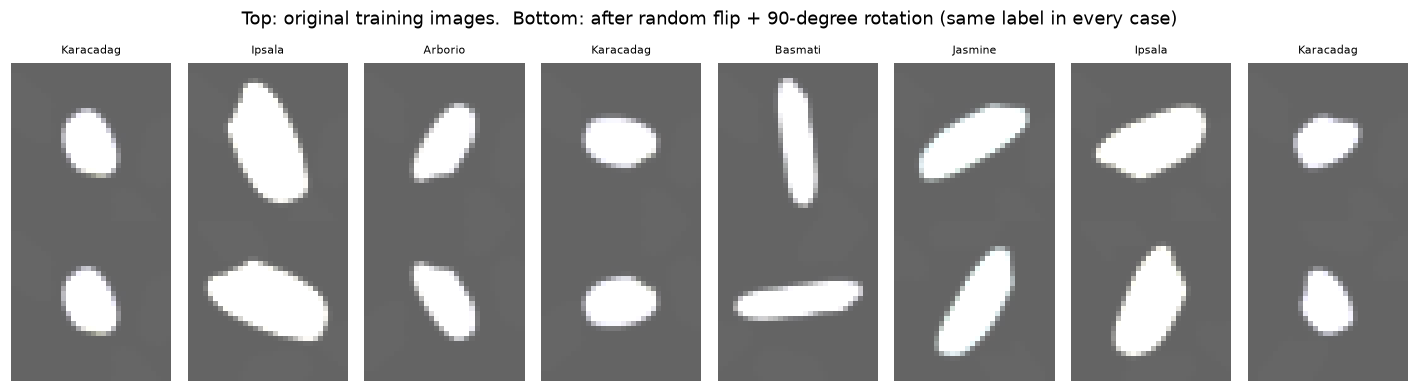

In [10]:
# Show what the model is actually being fed.
U.set_seed(U.SEED)
sample = torch.tensor(X_train[:8])
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for j in range(8):
    axes[0, j].imshow(np.clip(X_train[j].transpose(1, 2, 0) * 0.25 + 0.5, 0, 1))
    aug = augment(sample[j:j + 1])[0].numpy()
    axes[1, j].imshow(np.clip(aug.transpose(1, 2, 0) * 0.25 + 0.5, 0, 1))
    axes[0, j].set_title(CLASSES[y_train[j]], fontsize=7)
    axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("augmented")
fig.suptitle("Top: original training images.  Bottom: after random flip + 90-degree rotation "
             "(same label in every case)")
fig.tight_layout(); plt.show()

In [11]:
AUG_BASE = "M2  + BatchNorm"      # the best cheap model from the ladder

print(f"=== {AUG_BASE} without augmentation ===")
model_plain, rec_plain = train_with_augmentation(AUG_BASE, use_aug=False)

print(f"\n=== {AUG_BASE} with augmentation ===")
model_aug, rec_aug = train_with_augmentation(AUG_BASE, use_aug=True)

aug_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("history", "confusion")}
    for r in (rec_plain, rec_aug)
])
display(aug_df.round(4))

delta = rec_aug["test_accuracy"] - rec_plain["test_accuracy"]
print(f"\naugmentation changed accuracy by {delta:+.4f} "
      f"({100 * delta:+.2f} points) for 0 extra parameters")
print(f"train loss: {rec_plain['train_loss']:.4f} -> {rec_aug['train_loss']:.4f}")

=== M2  + BatchNorm without augmentation ===


  epoch  1/10  loss 0.8222  test_acc 0.2305


  epoch  2/10  loss 0.2144  test_acc 0.8725


  epoch  3/10  loss 0.0932  test_acc 0.8655


  epoch  4/10  loss 0.0562  test_acc 0.9445


...

  epoch  8/10  loss 0.0366  test_acc 0.8395


  epoch  9/10  loss 0.0275  test_acc 0.9425


  epoch 10/10  loss 0.0273  test_acc 0.9775


,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,PyTorch,Rice (4k subset),M2 (no augmentation),72629,10,11.47,0.0127,0.9895,0.9895,0.9893,0.9894
1,PyTorch,Rice (4k subset),M2 + augmentation,72629,10,10.09,0.0273,0.9775,0.9783,0.9769,0.9770



augmentation changed accuracy by -0.0120 (-1.20 points) for 0 extra parameters
train loss: 0.0127 -> 0.0273


**How to read the training loss here.** Augmentation almost always *raises* it, because the model is being
asked a harder question every epoch — it never sees the same image twice. A higher training loss combined
with equal-or-better test accuracy is exactly what a working regulariser looks like, and it is the mirror
image of the M4 overfitting signature in §3: there, lower training loss came with worse generalisation.

---
## 5. Everything together

In [12]:
all_rows = [{k: v for k, v in r.items() if k not in ("history", "confusion")}
            for r in ladder + [rec_plain, rec_aug]]
final = pd.DataFrame(all_rows)[
    ["model", "dataset", "n_params", "epochs", "train_seconds",
     "train_loss", "test_accuracy", "f1_macro"]
]
display(final.round(4))

,model,dataset,n_params,epochs,train_seconds,train_loss,test_accuracy,f1_macro
0,M1 Conv+ReLU+Pool,Rice (4k subset),72405,10,2.46,0.4510,0.8015,0.8024
1,M2 + BatchNorm,Rice (4k subset),72629,10,6.45,0.0130,0.9895,0.9894
2,M3 + Residual,Rice (4k subset),75461,10,10.08,0.0076,0.9895,0.9893
3,M4 + Attention(SE),Rice (4k subset),78289,10,13.40,0.0052,0.9945,0.9945
4,M2 (no augmentation),Rice (4k subset),72629,10,11.47,0.0127,0.9895,0.9894
5,M2 + augmentation,Rice (4k subset),72629,10,10.09,0.0273,0.9775,0.9770


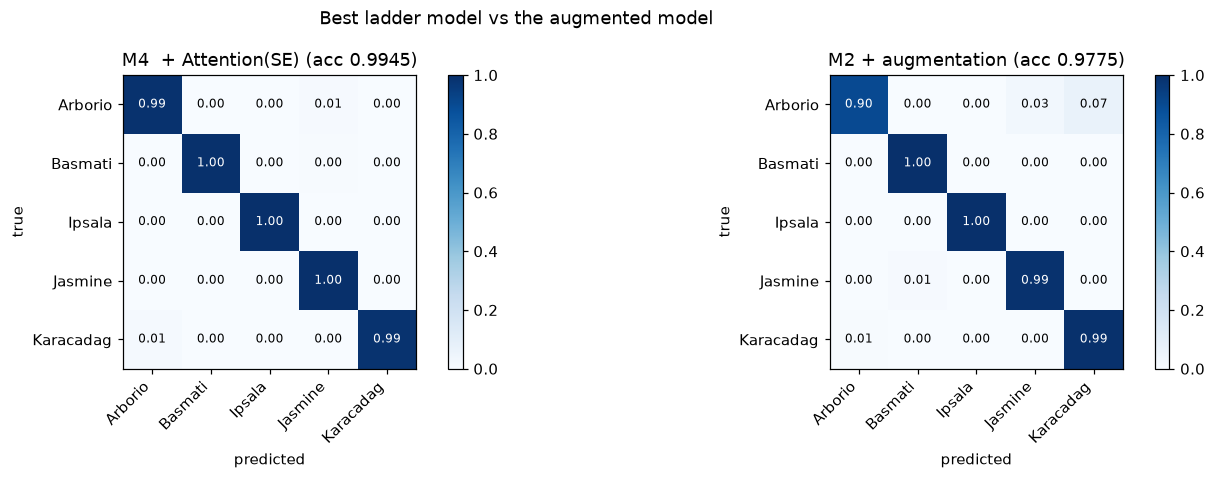

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

best_l = max(ladder, key=lambda r: r["test_accuracy"])
U.plot_confusion(best_l["confusion"], CLASSES,
                 title=f"{best_l['model']} (acc {best_l['test_accuracy']:.4f})", ax=axes[0])
U.plot_confusion(rec_aug["confusion"], CLASSES,
                 title=f"{rec_aug['model']} (acc {rec_aug['test_accuracy']:.4f})", ax=axes[1])
fig.suptitle("Best ladder model vs the augmented model")
fig.tight_layout(); plt.show()

In [14]:
# Cost per point of accuracy - the comparison theory_notes 3.3 makes implicitly.
m1 = ladder[0]
print(f"{'model':<24}{'+params':>10}{'+seconds':>10}{'+accuracy':>12}")
print("-" * 56)
for r in ladder:
    print(f"{r['model']:<24}{r['n_params'] - m1['n_params']:>10,}"
          f"{r['train_seconds'] - m1['train_seconds']:>10.0f}"
          f"{100 * (r['test_accuracy'] - m1['test_accuracy']):>+11.2f}")
print(f"{rec_aug['model']:<24}{0:>10,}"
      f"{rec_aug['train_seconds'] - rec_plain['train_seconds']:>10.0f}"
      f"{100 * (rec_aug['test_accuracy'] - rec_plain['test_accuracy']):>+11.2f}"
      "   (vs its own unaugmented twin)")

model                      +params  +seconds   +accuracy
--------------------------------------------------------
M1  Conv+ReLU+Pool               0         0      +0.00
M2  + BatchNorm                224         4     +18.80
M3  + Residual               3,056         8     +18.80
M4  + Attention(SE)          5,884        11     +19.30
M2 + augmentation                0        -1      -1.20   (vs its own unaugmented twin)


In [15]:
payload = {
    "dataset": DATASET,
    "subset": {"n_train": int(N_TRAIN), "n_test": int(N_TEST), "img_size": int(H)},
    "config": {"widths": V.WIDTHS, "epochs": V.EPOCHS,
               "batch_size": V.BATCH_SIZE, "lr": V.LR},
    "ladder": ladder,
    "augmentation": [rec_plain, rec_aug],
    "cifar10_reference": {
        "note": "theory_notes.md section 3.3, CIFAR-10 full 50k, for comparison",
        "M1": 0.6947, "M2": 0.7524, "M3": 0.7639, "M4": 0.7367,
    },
}
path = os.path.join(RESULTS, "n04_improved_cnn.json")
with open(path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, default=str)
print("saved", os.path.relpath(path, D.HERE))

saved results\n04_improved_cnn.json


In [16]:
TAG = "n04_improved_cnn"
U.save_model(model_plain, "m2_plain", TAG, architecture=rec_plain["model"], dataset=DATASET,
             epochs=rec_plain["epochs"], test_accuracy=rec_plain["test_accuracy"],
             f1_macro=rec_plain["f1_macro"], augmented=False)
U.save_model(model_aug, "m2_augmented", TAG, architecture=rec_aug["model"], dataset=DATASET,
             epochs=rec_aug["epochs"], test_accuracy=rec_aug["test_accuracy"],
             f1_macro=rec_aug["f1_macro"], augmented=True)

# M1..M4 weights are already in V.CACHE_DIR, written by train_variant.
print("\nM1..M4 weights cached at", os.path.relpath(V.CACHE_DIR, D.HERE))
print(sorted(os.listdir(V.CACHE_DIR)))
display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])

saved notebook\models\n04_improved_cnn\m2_plain.pt  (72,629 params, 299 KB)
saved notebook\models\n04_improved_cnn\m2_augmented.pt  (72,629 params, 299 KB)

M1..M4 weights cached at models\variant_cache_rice
['m1.json', 'm1.pt', 'm2.json', 'm2.pt', 'm3.json', 'm3.pt', 'm4.json', 'm4.pt']


,name,framework,n_params,dataset,test_accuracy
0,m2_augmented,torch,72629,Rice (4k subset),0.9775
1,m2_plain,torch,72629,Rice (4k subset),0.9895


---
## 6. What this experiment shows

**"New architecture = old architecture + a mechanism addressing a limitation" describes how architectures
evolve. It is not a promise that each addition improves accuracy.** That was the headline of
`theory_notes.md` §3.3 on CIFAR-10, and the tables above are this notebook's independent test of it.

Three things to read out of the numbers rather than assume:

1. **Does BatchNorm still pay for itself?** On CIFAR-10 it bought 5.77 points for 224 parameters — the
   textbook cheap-and-effective improvement. Check the `+params` / `+accuracy` columns in §5 for what it
   bought here.

2. **Does attention still hurt?** M4 lost to M3 on CIFAR-10, with the overfitting signature §3 describes —
   lowest training loss, worse test accuracy. The check in §3 reports whether that signature reappeared.
   An SE block was designed for deep networks like ResNet-50; bolted onto a three-stage ~78k-parameter
   model it may simply have no limitation left to fix, while its cost arrives immediately.

3. **How does a free improvement compare with a paid one?** Augmentation adds zero parameters and changes
   no architecture. If it competes with the mechanisms that do cost parameters, that is the most practical
   result in the notebook.

**Honest limits, the same ones §3.3 declares.** One seed per configuration, ten epochs, no hyperparameter
tuning, narrowed 16/32/64 stages, and a deliberately small 4,000-image training slice. These are *not*
competitive numbers for this dataset — notebook 02 reaches far higher with more data. They are a controlled
comparison in which exactly one thing changes at a time, which is a different goal from winning.

**And the result that outranks all four mechanisms**: notebook 02 showed that going from 5,000 to 60,000
images moved accuracy further than anything on this ladder. `theory_notes.md` §3.4 puts it best — *before
tuning the architecture, ask whether you have enough data.*